# Median House Value as a Softmax Regression Problem (Mini-batch update)

### Tensorflow 

Code by [D. Manrique](https://orcid.org/0000-0002-0792-4156)

## Import libraries

In [2]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())

## Helper libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

2.17.1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Load data

In [7]:
ATT_FILE = "MedianHouseValuePreparedCleanAttributes.csv"
LABEL_FILE = "MedianHouseValueOneHotEncodedClasses.csv"

TRAIN_RATE=0.8

attributes = pd.read_csv(ATT_FILE)
label = pd.read_csv(LABEL_FILE)

n_instances = attributes.shape[0]
n_train = int(n_instances*TRAIN_RATE)
n_dev = int((n_instances-n_train)/2)
#n_final_test = n_instances-n_train-n_dev

x_train = attributes.values[:n_train]
t_train = label.values[:n_train]

x_dev = attributes.values[n_train:n_train+n_dev]
t_dev = label.values[n_train:n_train+n_dev]

print ("x_train:",x_train.shape)
print ("t_train:",t_train.shape)

print ("x_dev:",x_dev.shape)
print ("t_dev:",t_dev.shape)

# We cannot employ the final test examples yet, since this is not the final neural approach.

x_train: (16342, 9)
t_train: (16342, 3)
x_dev: (2043, 9)
t_dev: (2043, 3)


## Initialize variables

In [9]:
INPUTS = x_train.shape[1]
OUTPUTS = t_train.shape[1]
NUM_TRAINING_EXAMPLES = int(round(x_train.shape[0]/1))
NUM_DEV_EXAMPLES = int (round (x_dev.shape[0]/1))

In [10]:
x_train[:5]

array([[-0.61752988,  0.11583422,  1.        , -0.81875986, -0.72346369,
        -0.9229799 , -0.72011182, -0.54388215,  0.33333333],
       [ 0.1812749 , -0.64718385, -0.09803922, -0.83997151, -0.71849783,
        -0.84041033, -0.72438744, -0.79931311, -1.        ],
       [ 0.33665339, -0.79383634, -0.45098039, -0.91144005, -0.92147734,
        -0.94730794, -0.91021214, -0.2504931 , -1.        ],
       [-0.93625498,  0.68119022,  0.29411765, -0.94892924, -0.93420236,
        -0.97533563, -0.94836376, -0.7090385 , -1.        ],
       [ 0.25697211, -0.68119022,  0.33333333, -0.91189786, -0.88764742,
        -0.9145716 , -0.88718961, -0.65516338, -1.        ]])

In [11]:
t_train[:5]

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [12]:
x_dev[:5]

array([[-0.61553785,  0.10945802,  1.        , -0.89389084, -0.84916201,
        -0.93951624, -0.83982898, -0.69925932,  0.33333333],
       [-0.17131474,  0.17534538,  0.64705882, -0.99491327, -0.99441341,
        -0.99770173, -0.99605328, -1.        , -0.33333333],
       [ 0.02390438, -0.63443146,  0.17647059, -0.98870746, -0.97299814,
        -0.98189411, -0.97138629, -0.74136908,  1.        ],
       [ 0.29083665, -0.65993624,  0.1372549 , -0.87318785, -0.81843575,
        -0.93632109, -0.81647755, -0.66378395, -0.33333333],
       [ 0.20717131, -0.68119022,  0.84313725, -0.93127829, -0.84885164,
        -0.89114045, -0.84015787, -0.7329692 , -1.        ]])

In [13]:
t_dev[:5]

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [14]:
x_train = tf.cast(x_train,tf.float32)
t_train = tf.cast(t_train,tf.float32)
x_dev = tf.cast(x_dev,tf.float32)
t_dev = tf.cast(t_dev,tf.float32)

## Set hyperparameters

We must adjust a new hiperparameter: the size of the mini-batch, $m$.

Instead of epochs (number of times the entire dataset is presented to the network) we employ iterations or steps (number of parameters updates) as the stop condition for the mini-batch gradient descent learning algorithm.

In [17]:
n_iterations = 20000
learning_rate = 0.1
batch_size =256

## Build the neural model: a logistic classifier

In [19]:
W = tf.Variable (tf.random.uniform ([INPUTS,OUTPUTS],-1,1), name="W")
b = tf.Variable (tf.zeros([OUTPUTS]), name = "bias")

Compute the *logits* (net input) and the output $y$ with the *Softmax* activation function:

In [21]:
def predict (X):
  return tf.nn.softmax (logits=net(X), name="y")

def net (X):
  return tf.add (tf.matmul(X,W), b, name="net")

The *cross-entropy* loss $\mathcal{L}$ and and *cost* $J$ (the mean of cross-entropy) functions:

$J(W) = \frac{1}{m}\sum_{p=1}^{m}\mathcal{L}^{(p)}(y,t)$;

$\mathcal{L}^{(p)}(y,t)=-\sum_{i=1}^{n_y}t_i\log (y_i).$

In [23]:
def mean_log_loss (n,t):
  cross_entropy = tf.nn.softmax_cross_entropy_with_logits (labels=t, logits=n)
  return tf.reduce_mean (cross_entropy, name="cost")

The training algorithm is the gradient descent method with the *softmax* function in the output neurons

In [25]:
def training_op(x, t, alpha_lr):
        #First the we compute the error
        with tf.GradientTape(persistent=True) as g: #persistent=True so parameters can change more than once
            error = mean_log_loss(net(x),t)

        #Then, the partial derivative of the error function regarding the weights; i.e., the parameters W and b
        dE_dW = g.gradient(error, W)
        dE_db = g.gradient(error, b)

        #Finally, we multiply the partial derivative by the learning rate and apply the increment
        W.assign_sub(alpha_lr * dE_dW)
        b.assign_sub(alpha_lr * dE_db)

        return error

Model evaluation: accuracy, the percentage of correctly classified instances.

In [27]:
def correct_predictions (y,t):
  return tf.equal(tf.argmax(y,1),tf.argmax(t,1))

def accuracy (y,t):
  return tf.reduce_mean(tf.cast(correct_predictions(y,t),tf.float32))

## Traing the model
Gradient descent approach (delta rule) with a mini-batch update strategy (M-BGD)

In [29]:
accuracy_train_history = np.empty([n_iterations])
error_train_history = np.empty([n_iterations])
for iteration in tqdm(range(n_iterations)):
  offset = (iteration * batch_size) % (NUM_TRAINING_EXAMPLES - batch_size)
  error = training_op (x_train[offset:(offset+batch_size)],
                       t_train[offset:(offset+batch_size)], learning_rate)
  accuracy_train_history[iteration] = accuracy (predict(x_train[offset:(offset+batch_size)]),
                                                        t_train[offset:(offset+batch_size)])
  error_train_history[iteration] = error


100%|████████████████████████████████████| 20000/20000 [00:45<00:00, 441.46it/s]


## Get the results

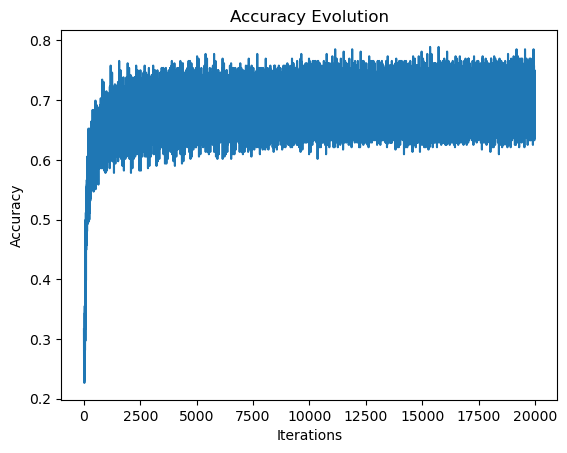

In [31]:
plt.title ("Accuracy Evolution")
plt.xlabel ("Iterations")
plt.ylabel ("Accuracy")
plt.plot (range(n_iterations),accuracy_train_history)

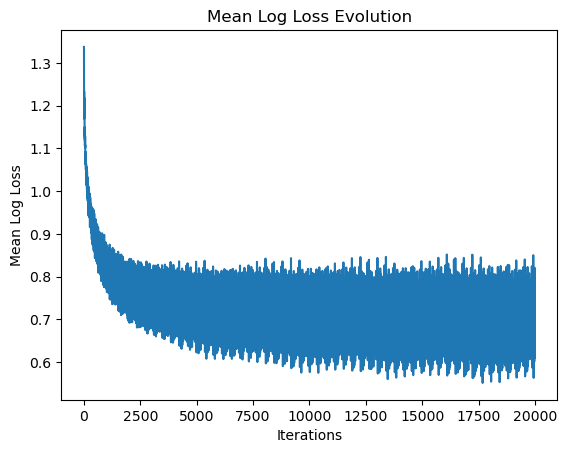

In [32]:
plt.title ("Mean Log Loss Evolution")
plt.xlabel ("Iterations")
plt.ylabel ("Mean Log Loss")
plt.plot (range(n_iterations),error_train_history)

Note that $zig$-$zags$ are due to mini-batch $zig$-$zagging$ errors.

In [34]:
final_accuracy_train = accuracy (predict(x_train),t_train)
final_accuracy_dev = accuracy (predict(x_dev),t_dev)
final_train_mean_log_loss = mean_log_loss(net(x_train),t_train)
final_dev_mean_log_loss = mean_log_loss(net(x_dev),t_dev)

print ("Final Accuracy in training: "+str(final_accuracy_train.numpy()))
print ("Final Accuracy for the development test set: "+str(final_accuracy_dev.numpy()))
print ("Final training mean-log-loss in training: "+str(final_train_mean_log_loss.numpy()))
print ("Final mean-log-loss for the development test set: "+str(final_dev_mean_log_loss.numpy()))

Final Accuracy in training: 0.70523804
Final Accuracy for the development test set: 0.7058248
Final training mean-log-loss in training: 0.6730813
Final mean-log-loss for the development test set: 0.6654895


In [35]:
predictions = predict(x_dev)
predictions[:20].numpy()

array([[2.51798064e-01, 3.39144856e-01, 4.09057021e-01],
       [9.93133068e-01, 6.83739129e-03, 2.94870642e-05],
       [4.32318151e-01, 4.08848137e-01, 1.58833727e-01],
       [4.93929833e-01, 4.24543709e-01, 8.15264285e-02],
       [3.55718493e-01, 4.91745055e-01, 1.52536437e-01],
       [4.70668763e-01, 4.55166847e-01, 7.41643831e-02],
       [9.35967565e-01, 6.30009547e-02, 1.03147130e-03],
       [3.48659828e-02, 2.65828758e-01, 6.99305236e-01],
       [9.40031469e-01, 5.94444014e-02, 5.24259172e-04],
       [6.36621892e-01, 3.34440142e-01, 2.89380047e-02],
       [1.25658838e-02, 1.99863896e-01, 7.87570238e-01],
       [1.75864384e-01, 5.81854105e-01, 2.42281437e-01],
       [2.47188320e-04, 4.10486795e-02, 9.58704114e-01],
       [2.83021536e-02, 4.50738966e-01, 5.20958781e-01],
       [6.81844875e-02, 5.24219275e-01, 4.07596231e-01],
       [3.25876661e-02, 2.54326701e-01, 7.13085592e-01],
       [9.69589710e-01, 3.01490501e-02, 2.61242036e-04],
       [8.05052757e-01, 1.85270

In [36]:
rounded_predictions=np.round(predictions)
indices = np.argmax(predictions,1)
for row, index in zip(rounded_predictions, indices): row[index]=1
rounded_predictions[:20]

array([[0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]], dtype=float32)

In [37]:
t_dev[:20].numpy()

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]], dtype=float32)

In [38]:
dev_predictions = correct_predictions(predict(x_dev),t_dev).numpy()
dev_predictions[:20]

array([ True, False,  True, False, False, False, False,  True,  True,
        True,  True, False, False, False,  True,  True,  True,  True,
        True,  True])

In [39]:
from collections import Counter
Counter(dev_predictions)

Counter({True: 1442, False: 601})